计算不同流量量级下的模型表现...

流量量级NSE:
LR: ['-0.014', '-4.736', '-0.870', '0.000', '-1.783', '0.727']
ANN: ['0.153', '-1.751', '0.020', '0.141', '-1.726', '0.783']
RF: ['-0.478', '-3.815', '-0.498', '-0.169', '-2.218', '-0.361']
XGB: ['0.077', '-1.851', '0.046', '0.001', '-1.804', '0.470']

流量量级RMSE:
LR: ['48.7', '82.7', '131.2', '172.7', '293.2', '684.9']
ANN: ['44.5', '57.3', '95.0', '160.0', '290.2', '611.6']
RF: ['58.8', '75.8', '117.4', '186.7', '315.2', '1530.0']
XGB: ['46.5', '58.3', '93.7', '172.6', '294.3', '954.6']

流量量级样本数:
分布: [818, 824, 823, 492, 165, 165]

生成流量量级综合评估图表...
✓ Magnitude evaluation chart saved to: results/Figure3_magnitude_evaluation.png

归一化信息:
  NSE范围: -4.736 - 0.783
  RMSE范围: 44.5 - 1530.0 m³/s
  NSE归一化: (NSE - -4.736) / (0.783 - -4.736)
  RMSE归一化: 1 - (RMSE - 44.5) / (1530.0 - 44.5)


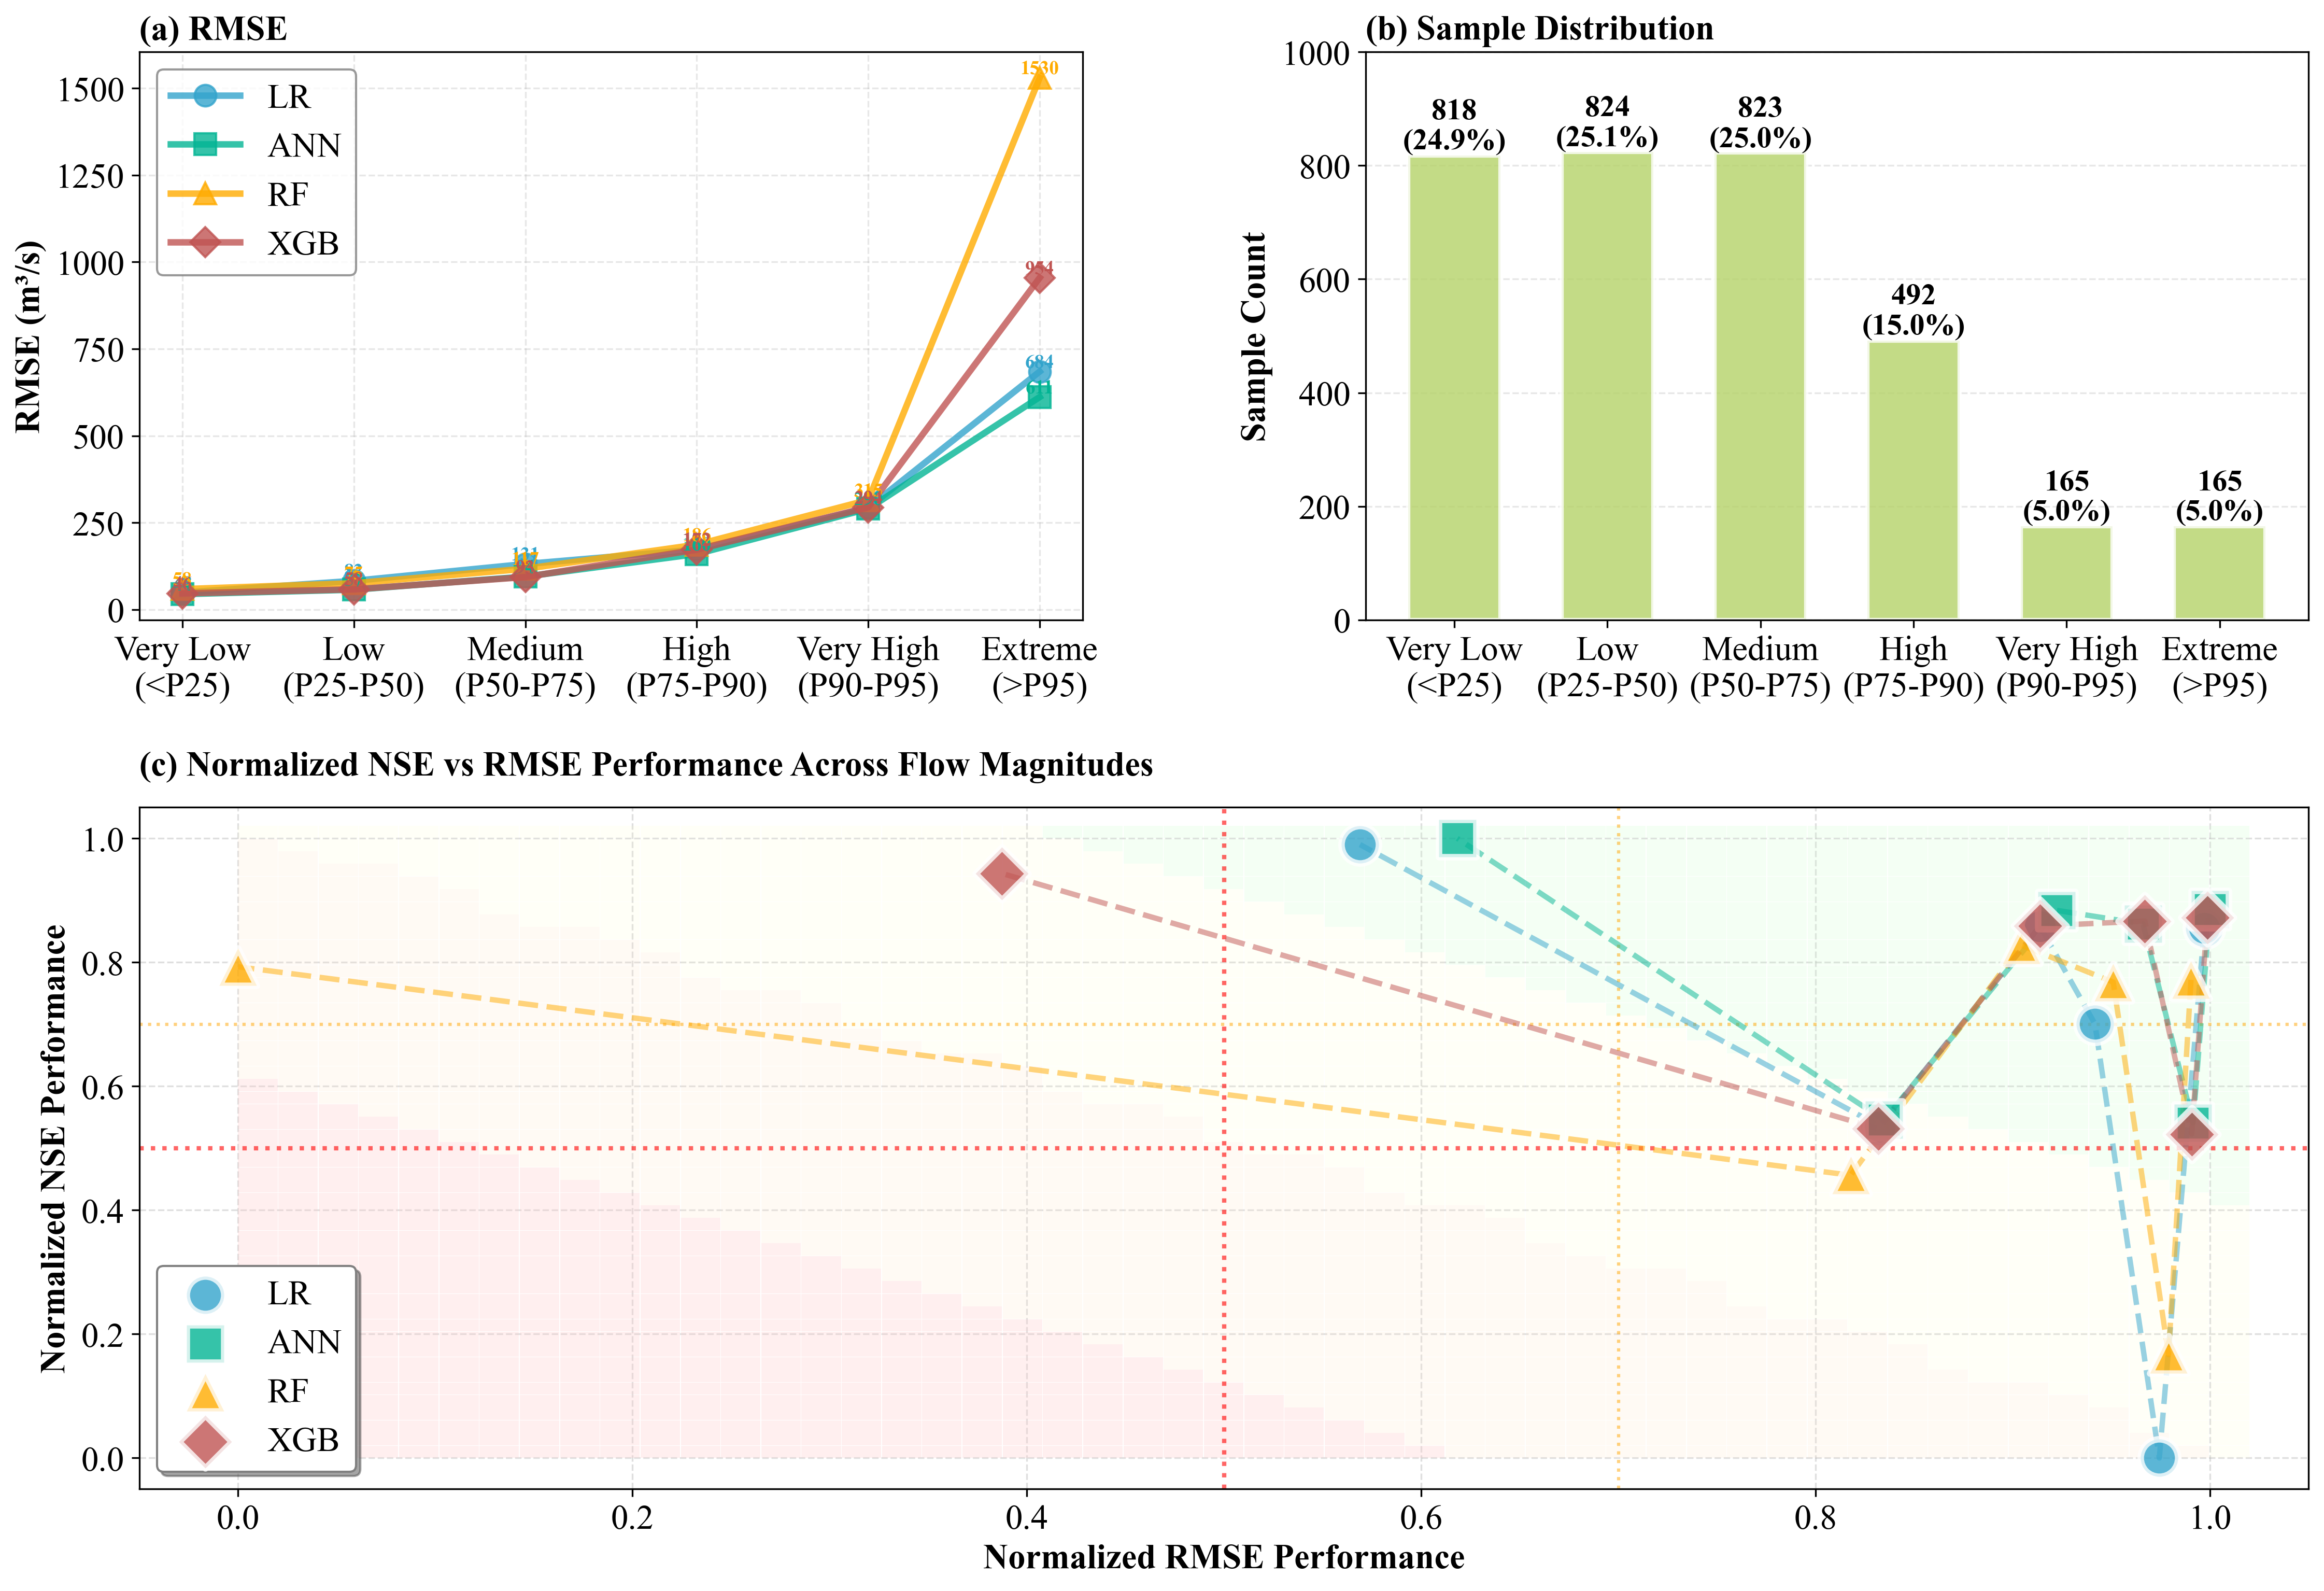


✓ 流量量级综合评估图表已生成！


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os

# 设置字体为英文罗马字体
plt.rcParams["font.family"] = ["Times New Roman"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 16
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["legend.fontsize"] = 16

def calculate_magnitude_performance(results_dir='results', percentiles=[25, 50, 75, 90, 95]):
    """
    计算4个模型在不同流量量级下的表现
    """
    models = ['LR', 'ANN', 'RF', 'XGB']
    
    magnitude_nse = {}
    magnitude_rmse = {}
    magnitude_mae = {}
    magnitude_count = {}
    
    for model in models:
        pred_file = f'predictions/with_typhoon_enhanced_{model}_predictions.csv'
        pred_df = pd.read_csv(pred_file)
        
        obs = pred_df['observed'].values
        pred = pred_df['predicted'].values
        
        # 计算分位数阈值
        thresholds = [np.percentile(obs, p) for p in percentiles]
        
        # 定义量级
        magnitude_labels = ['Very Low\n(<P25)', 'Low\n(P25-P50)', 'Medium\n(P50-P75)', 
                           'High\n(P75-P90)', 'Very High\n(P90-P95)', 'Extreme\n(>P95)']
        
        model_nse = []
        model_rmse = []
        model_mae = []
        model_count = []
        
        # 计算每个量级的指标
        for i in range(len(thresholds) + 1):
            if i == 0:
                mask = obs < thresholds[0]
            elif i == len(thresholds):
                mask = obs >= thresholds[-1]
            else:
                mask = (obs >= thresholds[i-1]) & (obs < thresholds[i])
            
            obs_mag = obs[mask]
            pred_mag = pred[mask]
            
            if len(obs_mag) > 5:
                # NSE
                nse_val = 1 - np.sum((obs_mag - pred_mag)**2) / np.sum((obs_mag - np.mean(obs_mag))**2)
                model_nse.append(nse_val)
                
                # RMSE
                rmse_val = np.sqrt(np.mean((obs_mag - pred_mag)**2))
                model_rmse.append(rmse_val)
                
                # MAE
                mae_val = np.mean(np.abs(obs_mag - pred_mag))
                model_mae.append(mae_val)
                
                # 样本数
                model_count.append(len(obs_mag))
            else:
                model_nse.append(np.nan)
                model_rmse.append(np.nan)
                model_mae.append(np.nan)
                model_count.append(0)
        
        magnitude_nse[model] = model_nse
        magnitude_rmse[model] = model_rmse
        magnitude_mae[model] = model_mae
        magnitude_count[model] = model_count
    
    return magnitude_nse, magnitude_rmse, magnitude_mae, magnitude_count, magnitude_labels

def plot_magnitude_combined(magnitude_nse, magnitude_rmse, magnitude_mae, magnitude_count, magnitude_labels,
                           output_file='results/Figure3_magnitude_evaluation.png',
                           figsize=(18, 12), dpi=300):
    """
    绘制组合图：
    - 上面一行：(a) RMSE折线图, (b) 样本分布
    - 下面一行：(c) 归一化NSE-RMSE散点图（占整行）
    """
    models = list(magnitude_nse.keys())
    colors = ['#33a4cc', '#02b494', '#ffab00', '#c05452']
    markers = ['o', 's', '^', 'D']
    
    # 归一化NSE和RMSE（仅用于图c）
    # 收集所有NSE和RMSE值
    all_nse = []
    all_rmse = []
    for model in models:
        all_nse.extend([v for v in magnitude_nse[model] if not np.isnan(v)])
        all_rmse.extend([v for v in magnitude_rmse[model] if not np.isnan(v)])
    
    nse_min = np.min(all_nse)
    nse_max = np.max(all_nse)
    rmse_min = np.min(all_rmse)
    rmse_max = np.max(all_rmse)
    
    # 归一化函数
    def normalize_nse(nse):
        """NSE归一化到0-1"""
        return (nse - nse_min) / (nse_max - nse_min)
    
    def normalize_rmse(rmse):
        """RMSE归一化到0-1，并反转（RMSE越小越好）"""
        return 1 - (rmse - rmse_min) / (rmse_max - rmse_min)
    
    # 创建图形和网格布局
    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2], hspace=0.3, wspace=0.3)
    
    # 添加总标题
    
    x = np.arange(len(magnitude_labels))
    
    # ==================== (a) RMSE折线图（原始值）====================
    ax1 = fig.add_subplot(gs[0, 0])
    
    for i, model in enumerate(models):
        values = np.array(magnitude_rmse[model])
        ax1.plot(x, values, marker=markers[i], markersize=10, linewidth=3,
                label=model, color=colors[i], alpha=0.8)
        
        # 添加数值标签
        for j, val in enumerate(values):
            if not np.isnan(val):
                ax1.text(j, val, f'{int(val)}', ha='center', va='bottom', 
                        fontsize=9, color=colors[i], fontweight='bold')
    
    ax1.set_ylabel('RMSE (m³/s)', fontsize=16, fontweight='bold')
    ax1.set_title('(a) RMSE', fontsize=16, fontweight='bold', loc='left')
    ax1.set_xticks(x)
    ax1.set_xticklabels(magnitude_labels, fontsize=16)
    ax1.legend(loc='upper left', fontsize=16, frameon=True, edgecolor='gray')
    ax1.grid(True, linestyle='--', alpha=0.3, linewidth=0.8)
    ax1.set_axisbelow(True)
    
    # ==================== (b) 样本数分布 ====================
    ax2 = fig.add_subplot(gs[0, 1])
    
    # 计算平均样本数
    avg_count = np.array(magnitude_count[models[0]])
    
    bars = ax2.bar(x, avg_count, width=0.6, color='#b5d268', 
                   edgecolor='white', linewidth=2, alpha=0.8)
    
    # 添加数值标签和百分比
    total_count = np.sum(avg_count)
    for bar, count in zip(bars, avg_count):
        height = bar.get_height()
        percentage = (count / total_count) * 100
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count)}\n({percentage:.1f}%)', 
                ha='center', va='bottom', fontsize=14, fontweight='bold')

    ax2.set_ylim([0, 1000])
    ax2.set_ylabel('Sample Count', fontsize=16, fontweight='bold')
    ax2.set_title('(b) Sample Distribution', fontsize=16, fontweight='bold', loc='left')
    ax2.set_xticks(x)
    ax2.set_xticklabels(magnitude_labels, fontsize=16)
    ax2.grid(axis='y', linestyle='--', alpha=0.3, linewidth=0.8)
    ax2.set_axisbelow(True)
    
    # ==================== (c) 归一化NSE-RMSE散点图（占整行）====================
    ax3 = fig.add_subplot(gs[1, :])  # 占据第二行的两列
    
    # 添加背景渐变（表示性能区域）
    from matplotlib.patches import Rectangle
    
    # 创建渐变背景
    for ix in np.linspace(0, 1, 50):
        for iy in np.linspace(0, 1, 50):
            # 综合得分：越靠近右上角颜色越绿
            score = (ix + iy) / 2
            if score < 0.3:
                color = '#ffcccc'  # 浅红
                alpha = 0.3
            elif score < 0.5:
                color = '#ffe6cc'  # 浅橙
                alpha = 0.2
            elif score < 0.7:
                color = '#ffffcc'  # 浅黄
                alpha = 0.15
            else:
                color = '#ccffcc'  # 浅绿
                alpha = 0.2
            
            rect = Rectangle((ix, iy), 0.02, 0.02, facecolor=color, alpha=alpha, zorder=1)
            ax3.add_patch(rect)
    
    for i, model in enumerate(models):
        nse_values = np.array(magnitude_nse[model])
        rmse_values = np.array(magnitude_rmse[model])
        
        # 归一化
        nse_norm = [normalize_nse(v) if not np.isnan(v) else np.nan for v in nse_values]
        rmse_norm = [normalize_rmse(v) if not np.isnan(v) else np.nan for v in rmse_values]
        
        # 绘制散点
        scatter = ax3.scatter(rmse_norm, nse_norm, s=300, marker=markers[i], 
                   label=model, color=colors[i], alpha=0.8, edgecolor='white', linewidth=3,
                   zorder=10)
        
        # 连接点形成轨迹
        ax3.plot(rmse_norm, nse_norm, linestyle='--', linewidth=2.5,
                color=colors[i], alpha=0.5, zorder=5)
        
    
    ax3.set_xlabel('Normalized RMSE Performance', 
                  fontsize=16, fontweight='bold')
    ax3.set_ylabel('Normalized NSE Performance', 
                  fontsize=16, fontweight='bold')
    ax3.set_title('(c) Normalized NSE vs RMSE Performance Across Flow Magnitudes', 
                 fontsize=16, fontweight='bold', loc='left', pad=15)
    ax3.legend(loc='lower left', fontsize=16, frameon=True, edgecolor='gray', 
              shadow=True, fancybox=True)
    ax3.grid(True, linestyle='--', alpha=0.4, linewidth=0.8)
    
    # 性能参考线
    ax3.axhline(y=0.5, color='red', linestyle=':', linewidth=2, alpha=0.6)
    ax3.axhline(y=0.7, color='orange', linestyle=':', linewidth=1.5, alpha=0.5)
    ax3.axvline(x=0.5, color='red', linestyle=':', linewidth=2, alpha=0.6)
    ax3.axvline(x=0.7, color='orange', linestyle=':', linewidth=1.5, alpha=0.5)
    
    ax3.set_xlim([-0.05, 1.05])
    ax3.set_ylim([-0.05, 1.05])
    ax3.set_axisbelow(True)
    
   
    # 保存图像
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    plt.savefig(output_file, dpi=dpi, bbox_inches='tight', pad_inches=0.3)
    print(f"✓ Magnitude evaluation chart saved to: {output_file}")
    
    # 打印归一化信息
    print(f"\n归一化信息:")
    print(f"  NSE范围: {nse_min:.3f} - {nse_max:.3f}")
    print(f"  RMSE范围: {rmse_min:.1f} - {rmse_max:.1f} m³/s")
    print(f"  NSE归一化: (NSE - {nse_min:.3f}) / ({nse_max:.3f} - {nse_min:.3f})")
    print(f"  RMSE归一化: 1 - (RMSE - {rmse_min:.1f}) / ({rmse_max:.1f} - {rmse_min:.1f})")
    
    plt.show()

if __name__ == "__main__":
    # 计算不同量级下的表现
    print("计算不同流量量级下的模型表现...")
    magnitude_nse, magnitude_rmse, magnitude_mae, magnitude_count, magnitude_labels = \
        calculate_magnitude_performance()
    
    # 打印结果检查
    print("\n流量量级NSE:")
    for model, values in magnitude_nse.items():
        print(f"{model}: {[f'{v:.3f}' if not np.isnan(v) else 'NaN' for v in values]}")
    
    print("\n流量量级RMSE:")
    for model, values in magnitude_rmse.items():
        print(f"{model}: {[f'{v:.1f}' if not np.isnan(v) else 'NaN' for v in values]}")
    
    print("\n流量量级样本数:")
    print(f"分布: {magnitude_count[list(magnitude_count.keys())[0]]}")
    
    # 绘制组合图
    print("\n生成流量量级综合评估图表...")
    plot_magnitude_combined(magnitude_nse, magnitude_rmse, magnitude_mae, magnitude_count, magnitude_labels)
    
    print("\n✓ 流量量级综合评估图表已生成！")